In [147]:
import pandas as pd

df = pd.read_csv("../data/sample_students.csv")
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

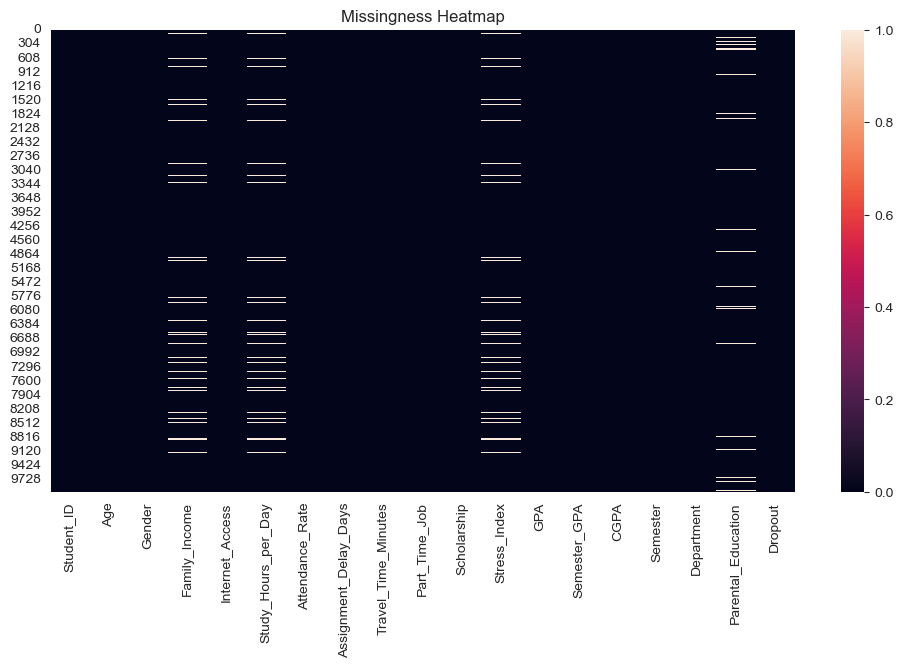

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull())
plt.title("Missingness Heatmap")
plt.savefig("../results/eda/missingness.png")
plt.show()

In [150]:
df = df.dropna(subset=["Student_ID","Gender"])
df.drop_duplicates(inplace=True)

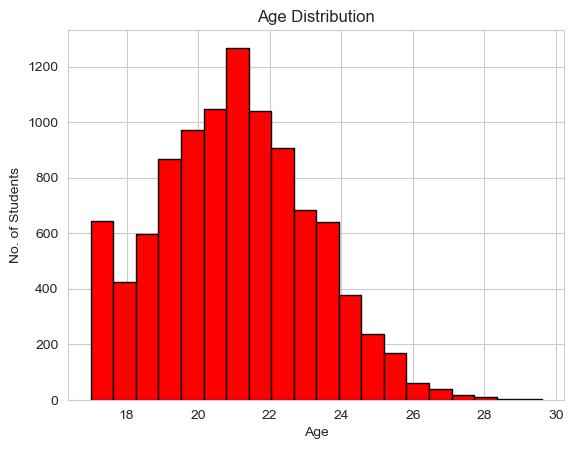

In [151]:
plt.hist(df["Age"], bins=20, color="red", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/age_hist.png")
plt.show()

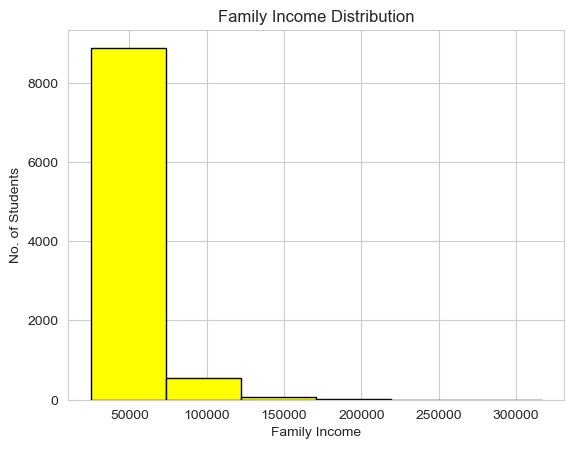

In [152]:
plt.hist(df["Family_Income"], bins=6, color="yellow", edgecolor="black")
plt.title("Family Income Distribution")
plt.xlabel("Family Income")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/family_income_hist.png")
plt.show()

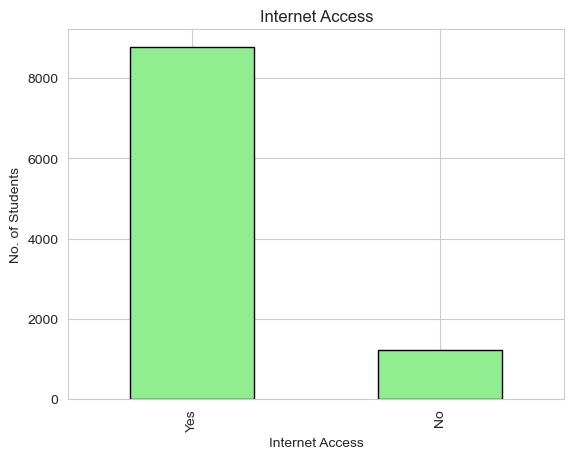

In [153]:
df['Internet_Access'].value_counts().plot(kind='bar', color="lightgreen", edgecolor="black")
plt.title("Internet Access")
plt.xlabel("Internet Access")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/internet_access_bar.png")
plt.show()

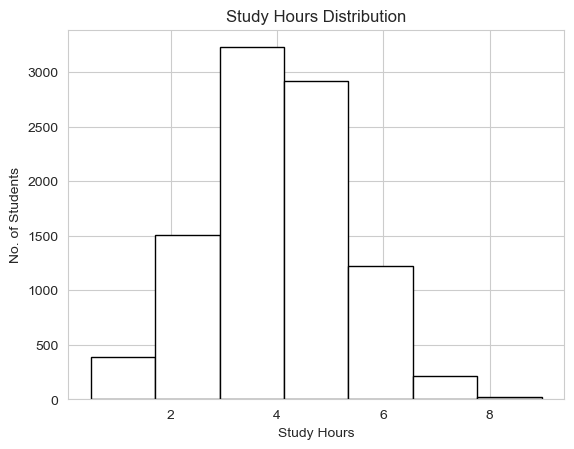

In [154]:
plt.hist(df["Study_Hours_per_Day"], bins=7, color="white", edgecolor="black")
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/study_hrs_hist.png")
plt.show()

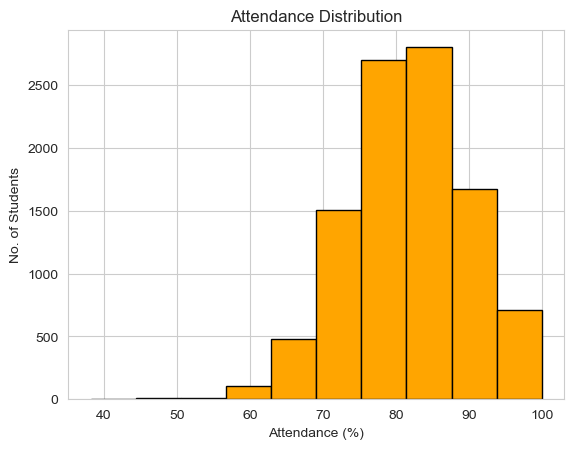

In [155]:
plt.hist(df["Attendance_Rate"], bins=10, color="orange", edgecolor="black")
plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/attendance_hist.png")
plt.show()

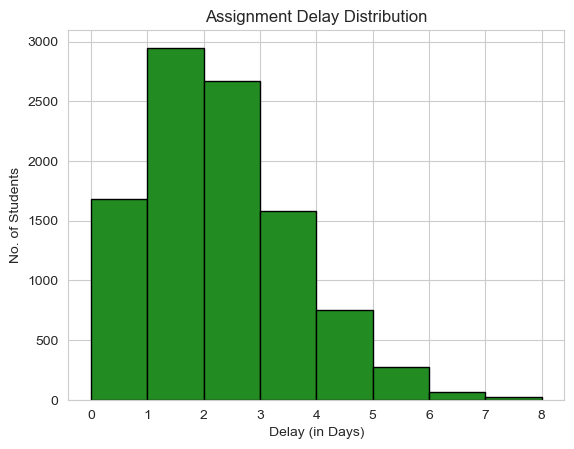

In [156]:
plt.hist(df["Assignment_Delay_Days"], bins=8, color="forestgreen", edgecolor="black")
plt.title("Assignment Delay Distribution")
plt.xlabel("Delay (in Days)")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/assign_delay_hist.png")
plt.show()

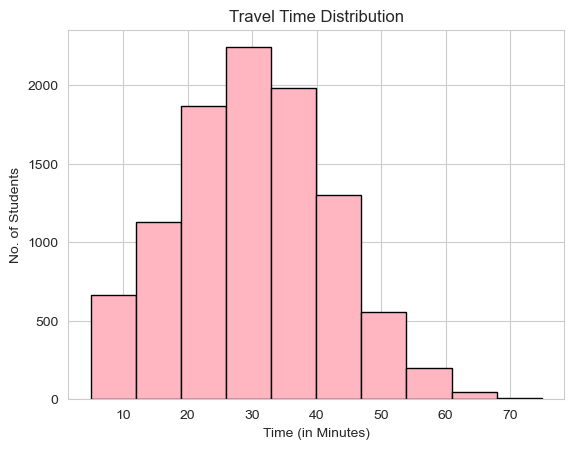

In [157]:
plt.hist(df["Travel_Time_Minutes"], bins=10, color="lightpink", edgecolor="black")
plt.title("Travel Time Distribution")
plt.xlabel("Time (in Minutes)")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/travel_time_hist.png")
plt.show()

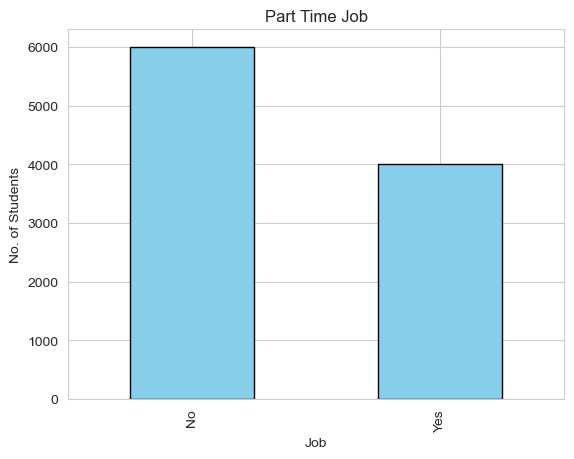

In [158]:
df['Part_Time_Job'].value_counts().plot(kind='bar', color="skyblue", edgecolor="black")
plt.title("Part Time Job")
plt.xlabel("Job")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/part_time_job.png")
plt.show()

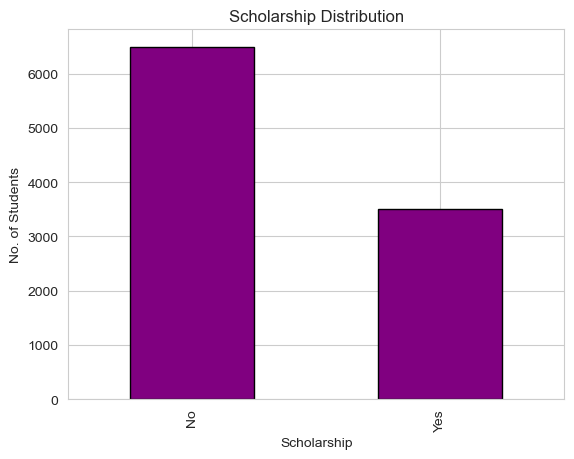

In [159]:
df['Scholarship'].value_counts().plot(kind='bar', color="purple", edgecolor="black")
plt.title("Scholarship Distribution")
plt.xlabel("Scholarship")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/scholarship.png")
plt.show()

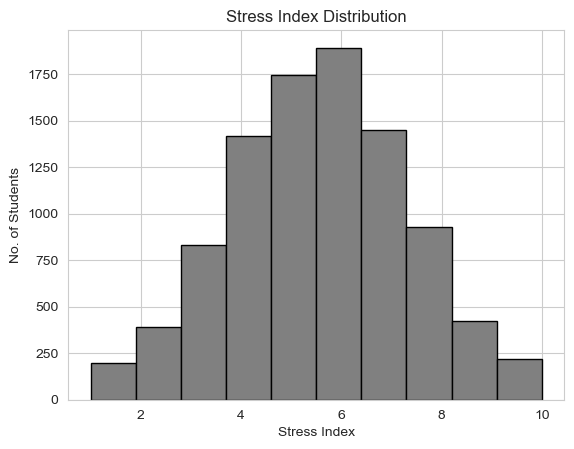

In [160]:
plt.hist(df["Stress_Index"], bins=10, color="grey", edgecolor="black")
plt.title("Stress Index Distribution")
plt.xlabel("Stress Index")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/stress_index_hist.png")
plt.show()

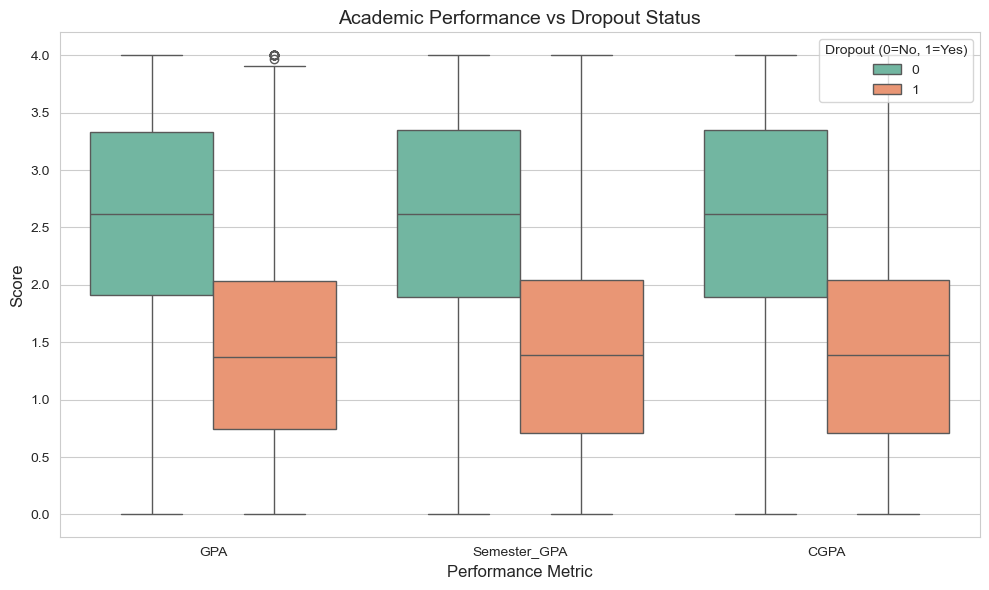

In [161]:
performance_df = df[["Dropout", "GPA", "Semester_GPA", "CGPA"]]

melted_df = performance_df.melt(
    id_vars="Dropout",
    var_name="Performance_Type",
    value_name="Score"
)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="Performance_Type",
    y="Score",
    hue="Dropout",
    data=melted_df
)
plt.title("Academic Performance vs Dropout Status", fontsize=14)
plt.xlabel("Performance Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(title="Dropout (0=No, 1=Yes)")
plt.tight_layout()
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.savefig("../results/eda/dropout_vs_grade.png")
plt.show()

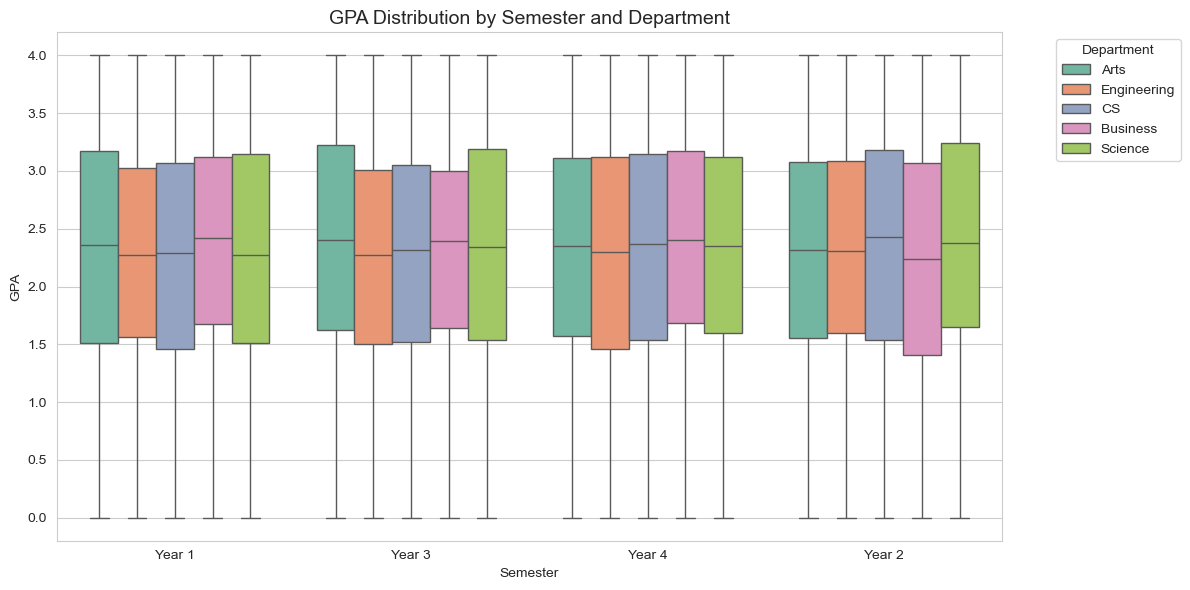

In [162]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Semester",
    y="GPA",
    hue="Department",
    data=df
)

plt.title("GPA Distribution by Semester and Department", fontsize=14)
plt.xlabel("Semester")
plt.ylabel("GPA")
plt.legend(title="Department", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("../results/eda/sem-dept_vs_gpa.png")
plt.show()

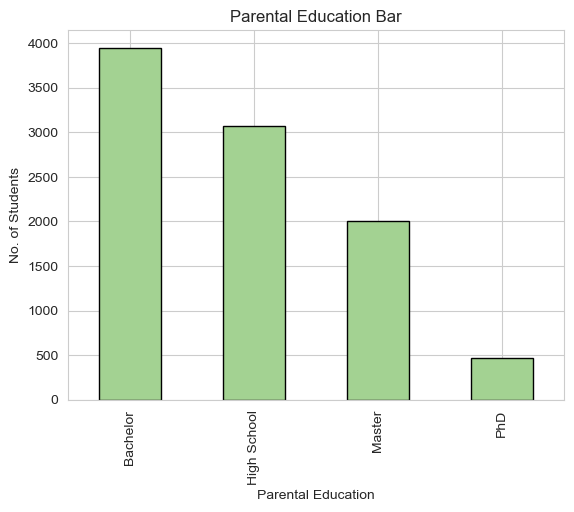

In [163]:
df['Parental_Education'].value_counts().plot(kind='bar', color="#A3D292", edgecolor="black")
plt.title("Parental Education Bar")
plt.xlabel("Parental Education")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/parental_edu_bar.png")
plt.show()

In [164]:
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
binary_cols = ["Internet_Access", "Scholarship", "Part_Time_Job"]
for col in binary_cols:
    df[col] = df[col].map({"Yes":1, "No":0})
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())
df["Parental_Education"] = df["Parental_Education"].fillna("Unknown")
df = pd.get_dummies(df, columns=["Parental_Education"], drop_first=True)

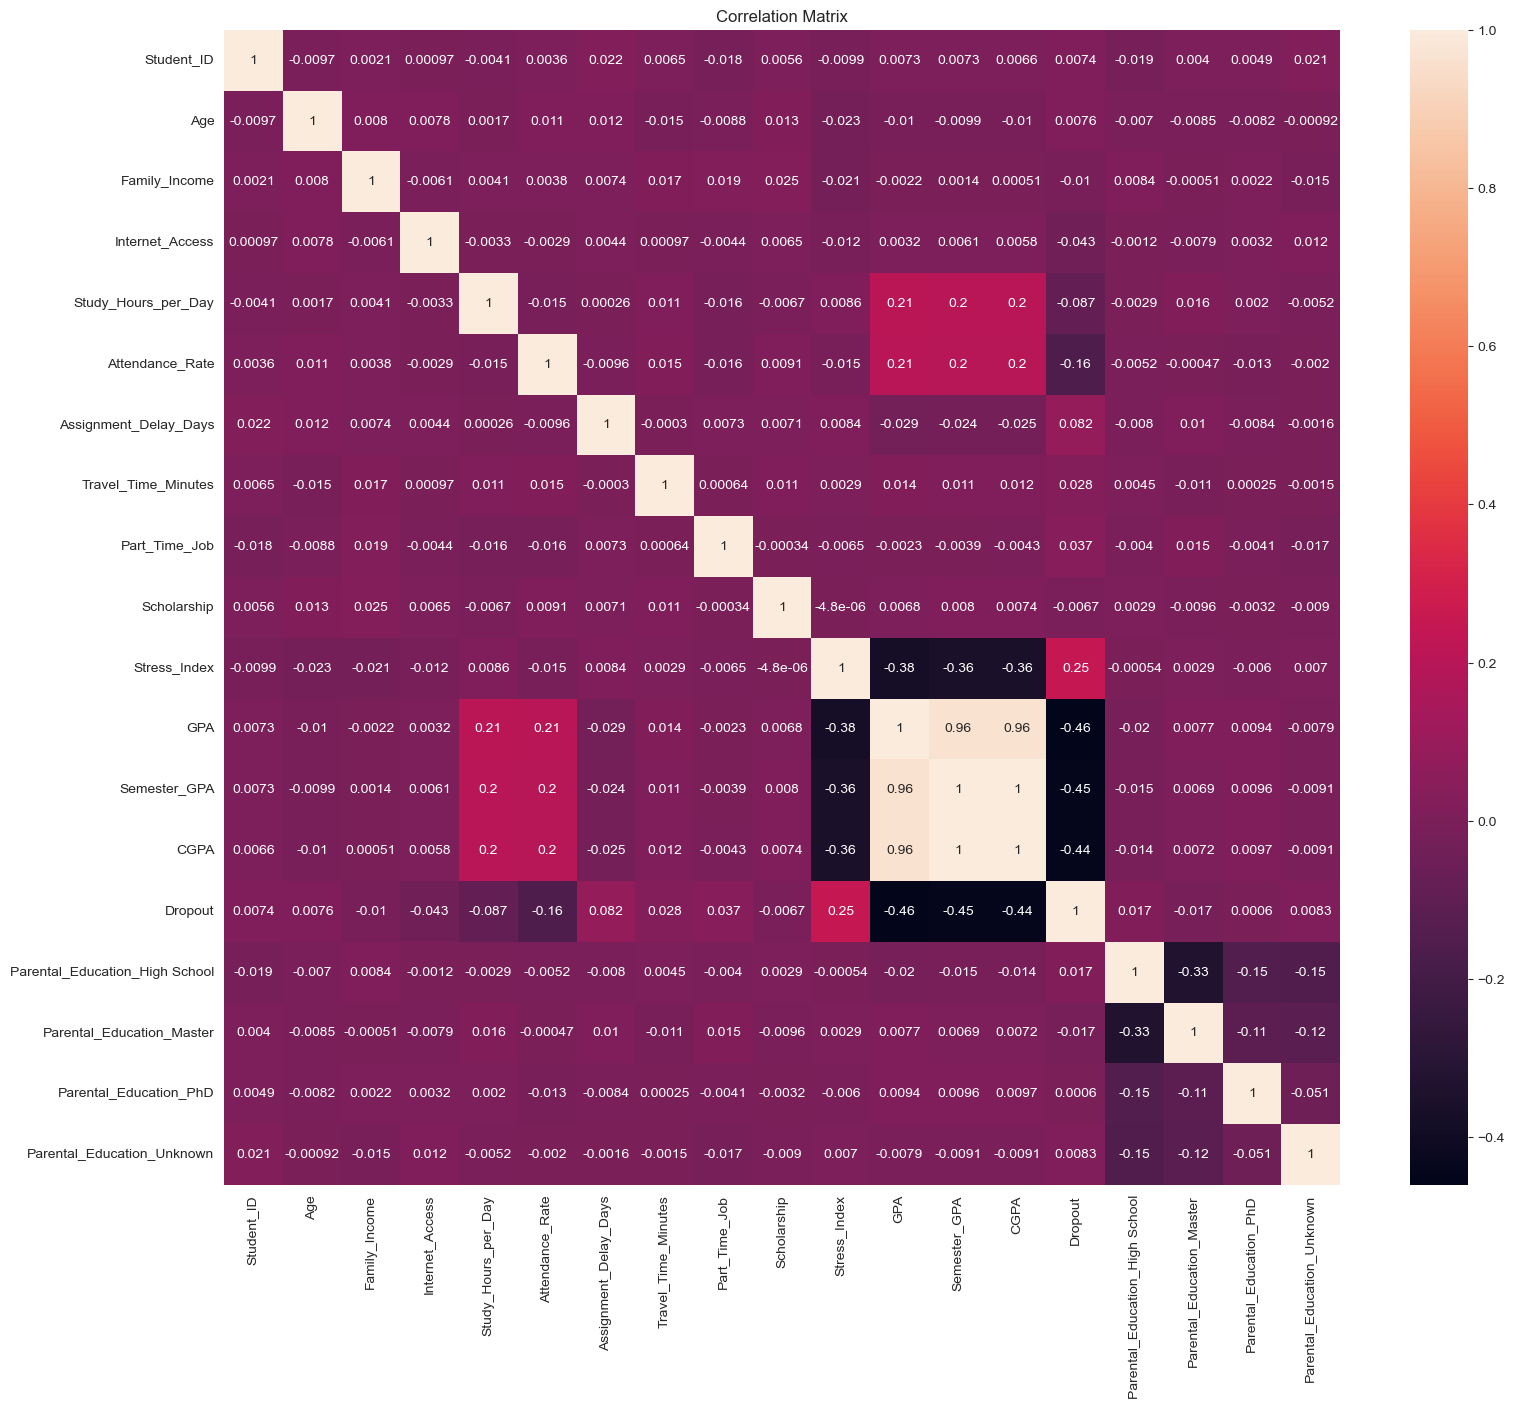

In [165]:
plt.figure(figsize=(18,15))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.savefig("../results/eda/corr.png")
plt.show()

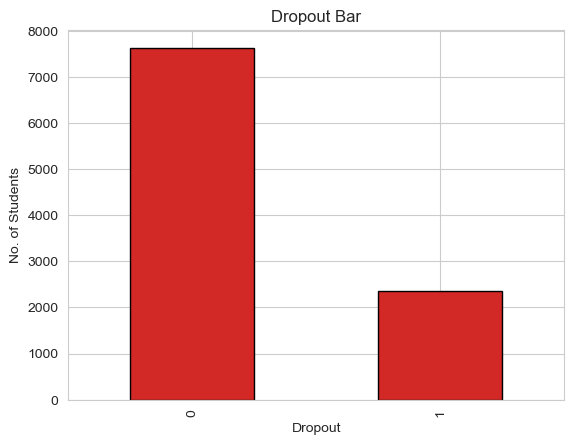

In [166]:
df['Dropout'].value_counts().plot(kind='bar', color="#D22826", edgecolor="black")
plt.title("Dropout Bar")
plt.xlabel("Dropout")
plt.ylabel("No. of Students")
plt.savefig("../results/eda/dropout_bar.png")
plt.show()